# Test of the SmolVLM2-2.2B-Instruct model

In [1]:
# pip install accelerate

from transformers import AutoProcessor, AutoModelForImageTextToText
from PIL import Image
import os
# import requests
import torch

model_id = "HuggingFaceTB/SmolVLM2-2.2B-Instruct"

# url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/bee.jpg"
# image = Image.open(requests.get(url, stream=True).raw)
BASE_DIR = os.getcwd()              # notebook directory
IMAGE_DIR = os.path.join(BASE_DIR, "..", "data")
image_path = os.path.join(IMAGE_DIR, "chicken_food.jpg")
image = Image.open(image_path).convert("RGB")


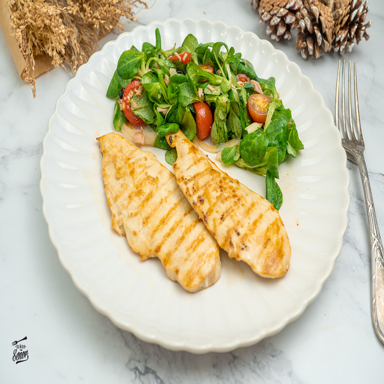

In [2]:
image = image.resize((384, 384))
display(image)

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [5]:
processor = AutoProcessor.from_pretrained(model_id)

model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    _attn_implementation="eager"
).to("cuda")


Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

In [6]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Can you describe this image?"},
        ]
    },
]

inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device, dtype=torch.bfloat16)

generated_ids = model.generate(**inputs, do_sample=False, max_new_tokens=64)
generated_texts = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True,
)
print(generated_texts[0])


User:




Can you describe this image?
Assistant: The image depicts a neatly arranged meal on a white plate with a scalloped edge. The plate contains two pieces of grilled chicken breast, which are golden brown and appear to be cooked to a medium-rare level. The chicken is placed on the left side of the plate.

To the right of the chicken,
